In [32]:
import pandas as pd

path = r"C:\Users\Fine Traders\Downloads\Lab 4\pandas_group_by\pandas_group_by\weather_by_cities.csv"

df = pd.read_csv(path)

df

,day,city,temperature,windspeed,event
0,1/1/2024,new york,32,6,Rain
1,1/2/2024,new york,36,7,Sunny
2,1/3/2024,new york,28,12,Snow
3,1/4/2024,new york,33,7,Sunny
4,1/1/2024,dubai,90,5,Sunny
5,1/2/2024,dubai,85,12,Fog
6,1/3/2024,dubai,87,15,Fog
7,1/4/2024,dubai,92,5,Rain
8,1/1/2024,paris,45,20,Sunny
9,1/2/2024,paris,50,13,Cloudy


In [33]:
g = df.groupby("city")
g

In [34]:
g.max()

,day,temperature,windspeed,event
city,,,,
dubai,1/4/2024,92,15,Sunny
new york,1/4/2024,36,12,Sunny
paris,1/4/2024,54,20,Sunny


In [35]:
g.get_group('new york')

,day,city,temperature,windspeed,event
0,1/1/2024,new york,32,6,Rain
1,1/2/2024,new york,36,7,Sunny
2,1/3/2024,new york,28,12,Snow
3,1/4/2024,new york,33,7,Sunny


In [36]:
for city, data in g:
    print("city:",city)
    print("\n")
    print("data:",data)

city: dubai


data:         day   city  temperature  windspeed  event
4  1/1/2024  dubai           90          5  Sunny
5  1/2/2024  dubai           85         12    Fog
6  1/3/2024  dubai           87         15    Fog
7  1/4/2024  dubai           92          5   Rain
city: new york


data:         day      city  temperature  windspeed  event
0  1/1/2024  new york           32          6   Rain
1  1/2/2024  new york           36          7  Sunny
2  1/3/2024  new york           28         12   Snow
3  1/4/2024  new york           33          7  Sunny
city: paris


data:          day   city  temperature  windspeed   event
8   1/1/2024  paris           45         20   Sunny
9   1/2/2024  paris           50         13  Cloudy
10  1/3/2024  paris           54          8  Cloudy
11  1/4/2024  paris           42         10  Cloudy


In [37]:
g.get_group('paris')

,day,city,temperature,windspeed,event
8,1/1/2024,paris,45,20,Sunny
9,1/2/2024,paris,50,13,Cloudy
10,1/3/2024,paris,54,8,Cloudy
11,1/4/2024,paris,42,10,Cloudy


In [38]:
g.min()

,day,temperature,windspeed,event
city,,,,
dubai,1/1/2024,85,5,Fog
new york,1/1/2024,28,6,Rain
paris,1/1/2024,42,8,Cloudy


In [39]:
g.mean(numeric_only=True)

,temperature,windspeed
city,,
dubai,88.50,9.25
new york,32.25,8.00
paris,47.75,12.75


In [40]:
g.size()

city
dubai       4
new york    4
paris       4
dtype: int64

In [41]:
g.count()

,day,temperature,windspeed,event
city,,,,
dubai,4,4,4,4
new york,4,4,4,4
paris,4,4,4,4


city
dubai       Axes(0.125,0.11;0.775x0.77)
new york    Axes(0.125,0.11;0.775x0.77)
paris       Axes(0.125,0.11;0.775x0.77)
dtype: object

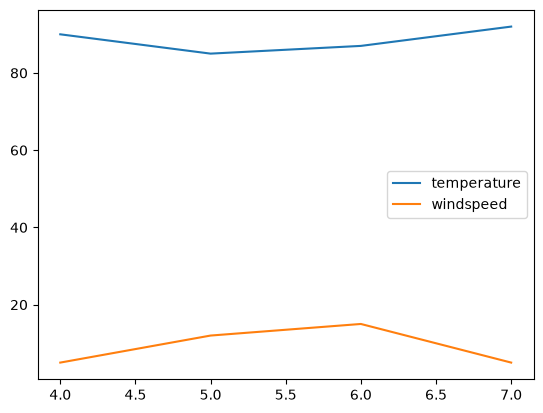

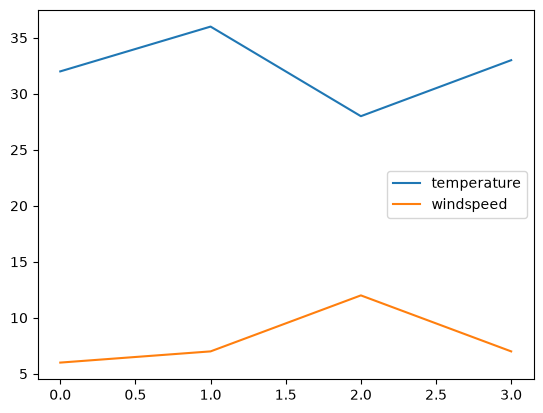

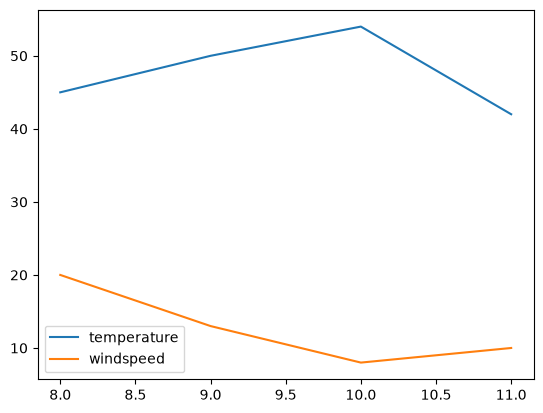

In [42]:
%matplotlib inline
g.plot()

In [43]:
def grouper(df, idx, col):
    if 80 <= df[col].loc[idx] <= 90:
        return '80-90'
    elif 50 <= df[col].loc[idx] <= 60:
        return '50-60'
    else:
        return 'others'

In [44]:
g = df.groupby(lambda x: grouper(df, x, 'temperature'))
g

In [45]:
for key, d in g:
    print("Group by Key: {}\n".format(key))
    print(d)

Group by Key: 50-60

         day   city  temperature  windspeed   event
9   1/2/2024  paris           50         13  Cloudy
10  1/3/2024  paris           54          8  Cloudy
Group by Key: 80-90

        day   city  temperature  windspeed  event
4  1/1/2024  dubai           90          5  Sunny
5  1/2/2024  dubai           85         12    Fog
6  1/3/2024  dubai           87         15    Fog
Group by Key: others

         day      city  temperature  windspeed   event
0   1/1/2024  new york           32          6    Rain
1   1/2/2024  new york           36          7   Sunny
2   1/3/2024  new york           28         12    Snow
3   1/4/2024  new york           33          7   Sunny
7   1/4/2024     dubai           92          5    Rain
8   1/1/2024     paris           45         20   Sunny
11  1/4/2024     paris           42         10  Cloudy
